In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

# Visualization Style

sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [24]:
df = pd.read_csv("dataset/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [25]:
print("Dataset Shape :", df.shape)

Dataset Shape : (1338, 7)


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [27]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [28]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [29]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

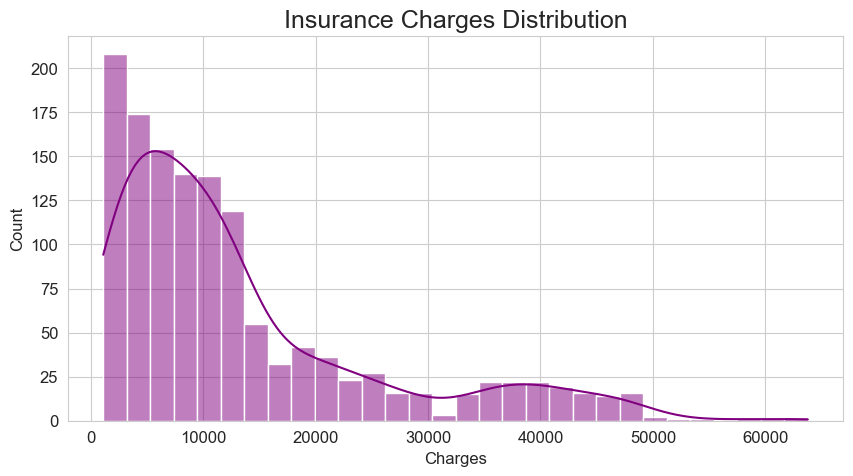

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['expenses'],
    bins=30,
    kde=True,
    color='purple'
)

plt.title("Insurance Charges Distribution", fontsize=18)

plt.xlabel("Charges")

plt.show()


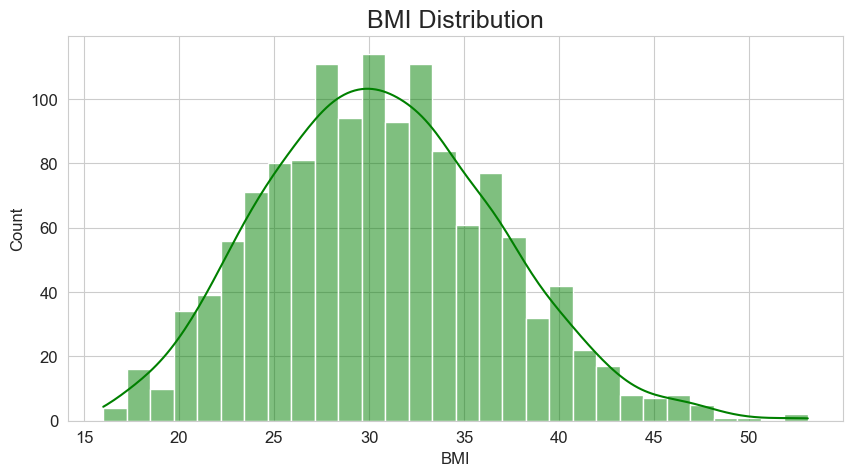

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['bmi'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("BMI Distribution", fontsize=18)

plt.xlabel("BMI")

plt.show()

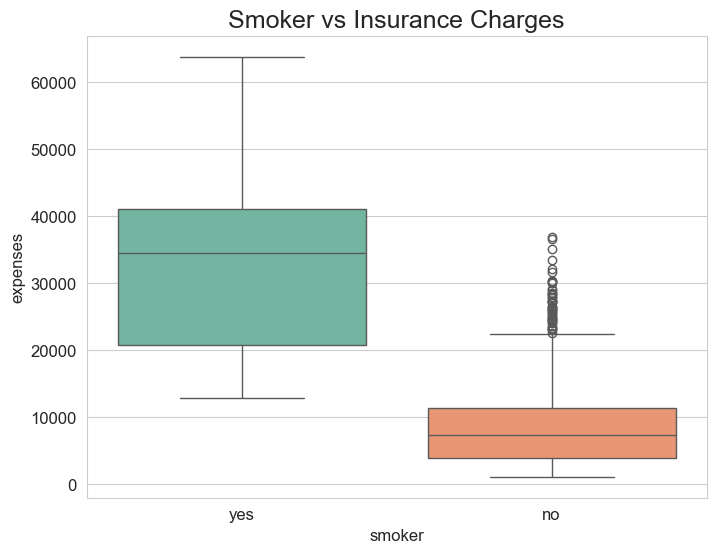

In [32]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='smoker',
    y='expenses',
    data=df,
    palette='Set2'
)

plt.title("Smoker vs Insurance Charges", fontsize=18)

plt.show()

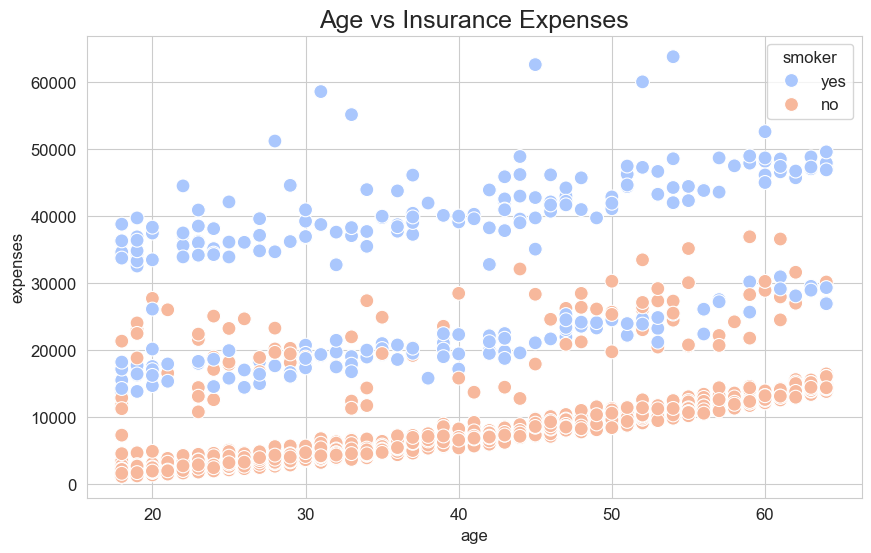

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='age',
    y='expenses',
    hue='smoker',
    data=df,
    palette='coolwarm',
    s=100
)

plt.title("Age vs Insurance Expenses", fontsize=18)

plt.show()

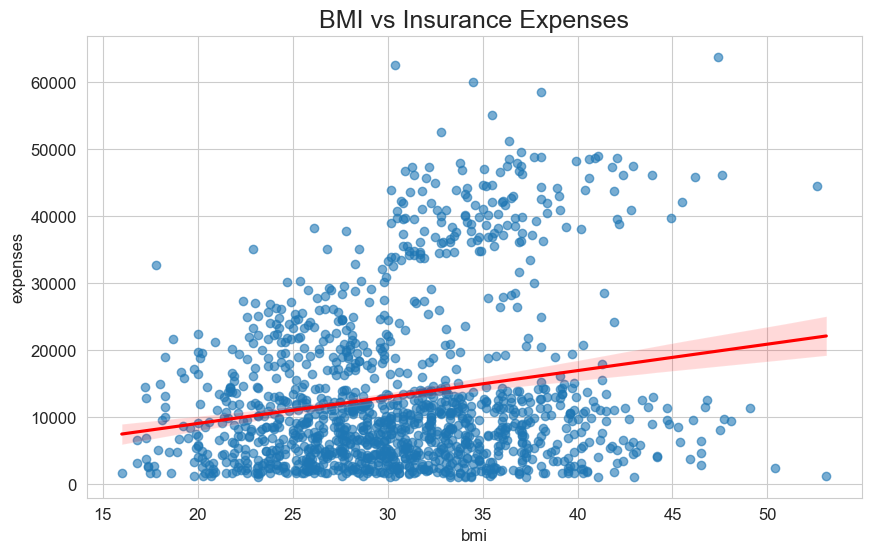

In [34]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='bmi',
    y='expenses',
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("BMI vs Insurance Expenses", fontsize=18)

plt.show()

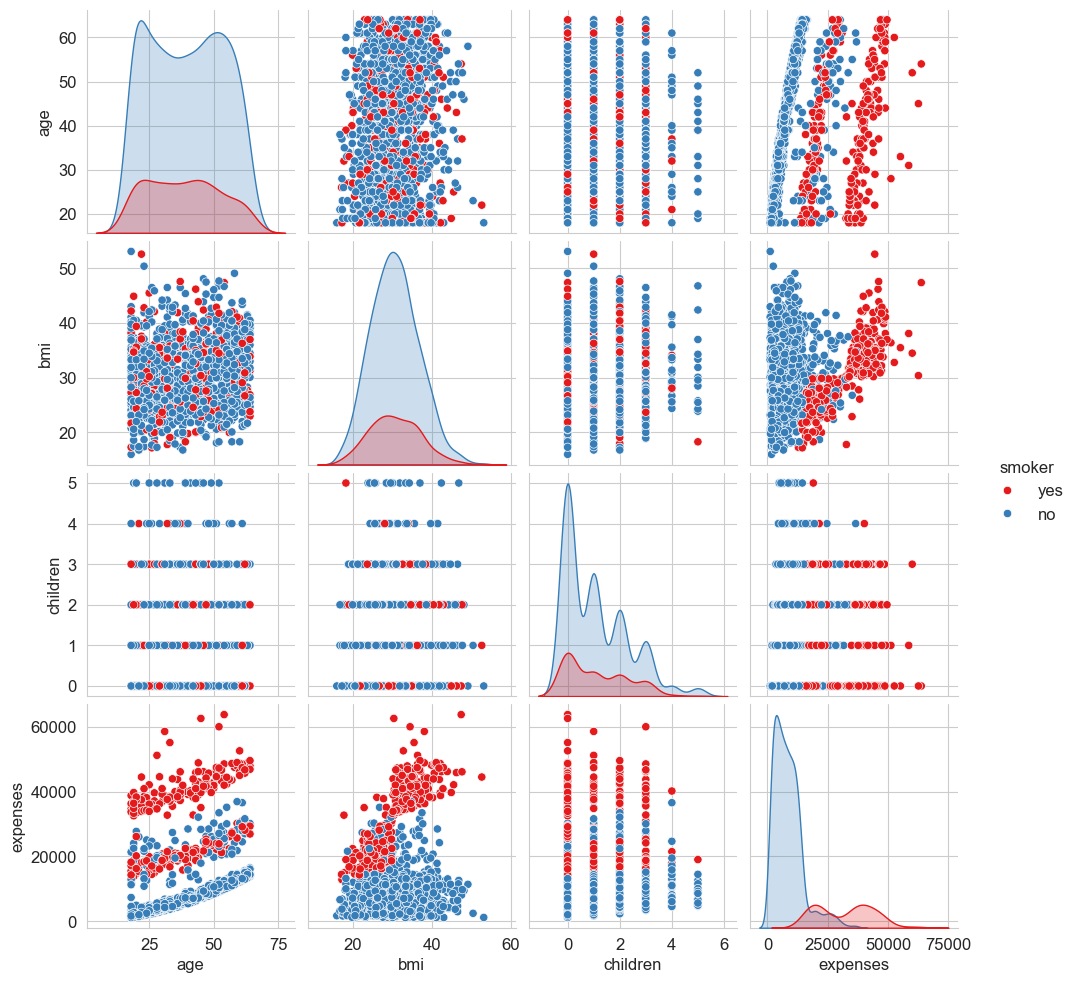

In [35]:
sns.pairplot(
    df[
        [
            'age',
            'bmi',
            'children',
            'expenses',
            'smoker'
        ]
    ],
    hue='smoker',
    palette='Set1'
)

plt.show()

In [36]:


encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = encoder.fit_transform(df[col])

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


In [37]:
X = df.drop('expenses', axis=1)

y = df['expenses']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [40]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [41]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE :", lr_mae)

print("Linear Regression RMSE :", lr_rmse)

print("Linear Regression R2 Score :", lr_r2)

Linear Regression MAE : 4186.940106317014
Linear Regression RMSE : 5799.920265829358
Linear Regression R2 Score : 0.7833214205203847


In [42]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", rf_mae)

print("Random Forest RMSE :", rf_rmse)

print("Random Forest R2 Score :", rf_r2)

Random Forest MAE : 2481.162827068111
Random Forest RMSE : 4563.360473362472
Random Forest R2 Score : 0.8658651938091546


In [44]:
models = pd.DataFrame({
    
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    
    'R2 Score': [
        lr_r2,
        rf_r2
    ]
})

models

,Model,R2 Score
0,Linear Regression,0.783321
1,Random Forest,0.865865


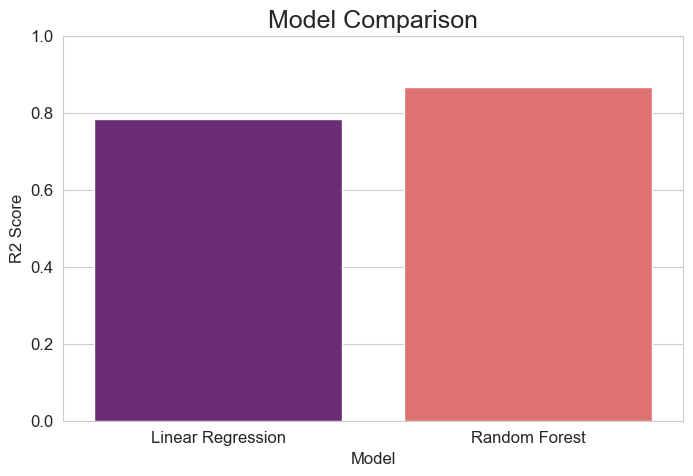

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=models,
    palette='magma'
)

plt.title("Model Comparison", fontsize=18)

plt.ylim(0,1)

plt.show()

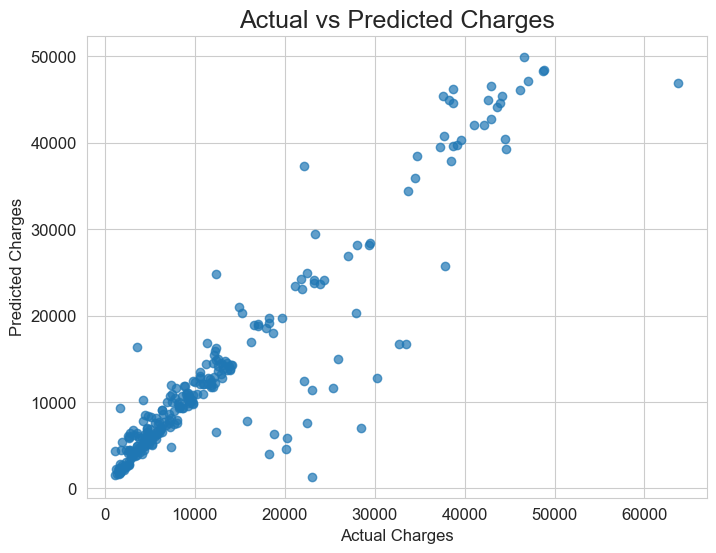

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.7
)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges", fontsize=18)

plt.show()

In [47]:
importance = pd.DataFrame({
    
    'Feature': X.columns,
    
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,smoker,0.617938
2,bmi,0.209854
0,age,0.133669
3,children,0.019265
5,region,0.013284
1,sex,0.005990


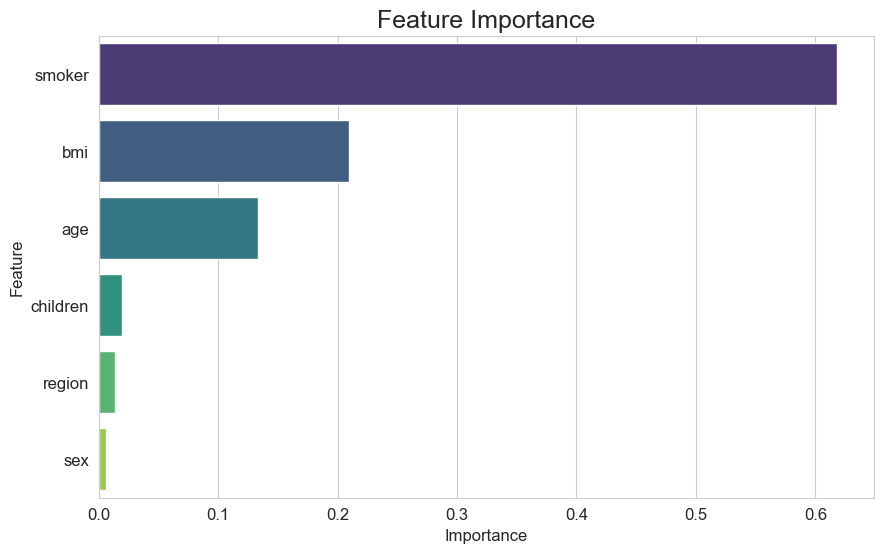

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette='viridis'
)

plt.title("Feature Importance", fontsize=18)

plt.show()